# Develop quick stuff

For temporary/quick stuff to be developed

In [4]:
import os
import sys

base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

from IPython.display import display, Markdown
import torch

from thesis.helper_scripts.general import extract_all_sim_objs, extract_biases_and_corrs_from_dirnames
from thesis.helper_scripts.sensitivity_analysis import extract_bayes_errors
from thesis.helper_scripts.hypothesis_visualization import (
  plot_lines_and_mains,
  generate_lines_for_diffs,
  gen_lines_from_diff_dict,
  construct_all_diffs_tensor,
  get_areas,
  normalize_areas,
  plot_heatmap_grid,
  wrapper_plot_grid_of_diffs_between_logit_and_acc,
  plot_acc_rates_per_round
)

from experiments.acceptance_loop_cv_based_MNAR import THRESHOLD_BASIS, METRIC_CATEGORIES
from berebasl.simulation.credit_data_simulation import CreditDataGenerator, GaussianMixture

print()

real_order =  []

for th in THRESHOLD_BASIS:
  for m in METRIC_CATEGORIES:
    real_order.append(th + '_' + m )

all_acc_vector_names = [th + '_' + m for th in THRESHOLD_BASIS for m in METRIC_CATEGORIES]

print(real_order, all_acc_vector_names)


['oracle_ks', 'oracle_roc', 'acc_based_ks', 'acc_based_roc'] ['oracle_ks', 'oracle_roc', 'acc_based_ks', 'acc_based_roc']


In [2]:
grid_path = '../berebasl/data/simulations/mnar_grid_hyp_testing'

grid_biases, grid_corrs = extract_biases_and_corrs_from_dirnames(grid_path)
grid_biases = dict(sorted(grid_biases.items(), key=lambda x: x[1]))
grid_corrs = dict(sorted(grid_corrs.items(), key=lambda x: x[1]))
all_sim_objs = extract_all_sim_objs(grid_path, grid_biases, grid_corrs)
base_sim_objs = all_sim_objs['0_0']['0_0']

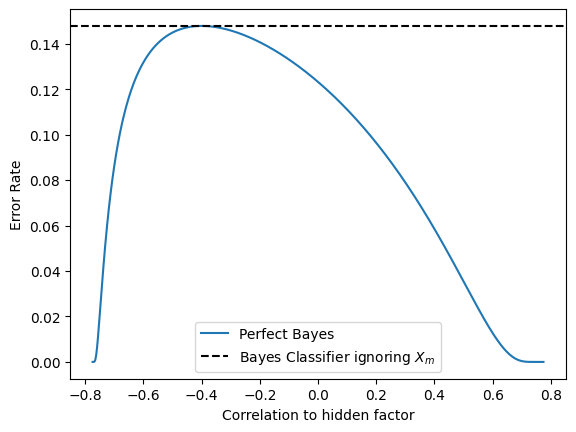

In [3]:
from matplotlib import pyplot as plt
from experiments.acceptance_loop_cv_based_MNAR import joint_mnar_default_dgp, mnar_default_dgp

corrs = torch.linspace(-0.7745966, 0.7745966, steps=500) # min and max corrs where still non singular and positive definite
dgp_all_corrs = joint_mnar_default_dgp(
    seed_credit_data_gen=1807,
    var_to_hide=base_sim_objs["var_to_hide"],
    hidden_corrs=corrs,
    deterministic_weights_for_mixture_sampling=False,
    device='cpu',
    dtype=torch.float32
)

bayes_errors = extract_bayes_errors(all_sim_objs, grid_biases, grid_corrs)

bayes_err_ignoring_var = bayes_errors[0,0,1].item()

bayes_errs_full = dgp_all_corrs.bayes_error_under_equal_covs()
plt.plot(corrs, bayes_errs_full, label="Perfect Bayes")
plt.axhline(
    y=bayes_err_ignoring_var,
    label="Bayes Classifier ignoring $X_m$",
    ls = "--",
    c="k"
)
plt.xlabel("Correlation to hidden factor")
plt.ylabel("Error Rate")

plt.legend()
plt.show()

In [143]:
import matplotlib as mpl
from math import sqrt

def _dummy_default_dgp(dtype=torch.float32) -> CreditDataGenerator:
    return mnar_default_dgp(
            seed_credit_data_gen=1807,
            var_to_hide=-1,
            hidden_corr=0,
            deterministic_weights_for_mixture_sampling=False,
            device='cpu',
            dtype=torch.float32
        )


def calc_all_permissible_bayes_err(max_corrs: int, encoding_no_hidden_was_zero: float | int, var_to_hide: int):
    assert encoding_no_hidden_was_zero < 0
    corr_space = torch.linspace(-1, 1, max_corrs+2)[1:-1]
    A, B = torch.meshgrid(corr_space, corr_space, indexing='ij')
    comb_AB = torch.stack([A, B], dim=-1)

    mask_valid_AB = B.square() < (1+A)/2
    valid_A_B = comb_AB[mask_valid_AB]

    dgp_for_canvass = _dummy_default_dgp()

    F = dgp_for_canvass.F
    V = valid_A_B.size(0)
    covs = dgp_for_canvass.good_mixture.cov_chol_decomp.new_ones(V, F, F)

    covs[:, [0, 1], [1,0]] = valid_A_B[:, 0].unsqueeze(-1)
    covs[:, [0,1,2, 2], [2,2,0,1]] = valid_A_B[:, 1].unsqueeze(-1)

    assert not torch.all(covs[0] == covs[1:], dim=(-2, -1)).any()

    vars_to_take_over = {
        vn : getattr(dgp_for_canvass, vn) for vn in [
                "prob_bad_given_no_shock",
                "prob_idiosyncratic_shock",
                "prob_bad_given_shock",
                "feats_noise_var"
            ]
    }

    dgp_with_all_valid = CreditDataGenerator(
        bad_mixture=GaussianMixture(
            mean=dgp_for_canvass.bad_mixture.mean.expand(V, F),
            cov=covs
        ),
        good_mixture=GaussianMixture(
            mean=dgp_for_canvass.good_mixture.mean.expand(V, F),
            cov=covs.clone()
        ),
        **vars_to_take_over
    )

    bayes_error_full_valids = dgp_with_all_valid.bayes_error_under_equal_covs()
    bayes_error_no_hidden_valids = dgp_with_all_valid.bayes_error_under_equal_covs(hidden_vars=[var_to_hide])

    assert torch.all(bayes_error_full_valids <= bayes_error_no_hidden_valids) # Must always be

    encoding_no_hidden_was_zero = -1

    normed_bayes_error = bayes_error_full_valids / bayes_error_no_hidden_valids
    normed_bayes_error.masked_fill_(bayes_error_no_hidden_valids==0, encoding_no_hidden_was_zero)


    normalized_normed_errors = torch.full_like(A, fill_value=float('nan'), dtype=normed_bayes_error.dtype)
    normalized_normed_errors[mask_valid_AB] = normed_bayes_error

    idxs_first_appearence_unique_corr_mh = torch.nn.functional.pad(mask_valid_AB.sum(dim=-1).cumsum(dim=-1)[:-1], pad=(1,0), value=0)
    bayes_err_no_hidden_valids_per_corr = bayes_error_no_hidden_valids[idxs_first_appearence_unique_corr_mh]

    return normalized_normed_errors, corr_space, bayes_err_no_hidden_valids_per_corr

def build_cmap_for_normalized_normed_errors(normalized_normed_errors: torch.Tensor):
    """
    This method does not require norming as errors are already normed in [0,1]
    """
    uniques = normalized_normed_errors.nan_to_num(nan=-float('inf')).unique(sorted=True)[1:]
    expected_to_be_dummy = uniques[0]
    assert expected_to_be_dummy < 0
    # --- 1. Build a continuous colormap from blue to red ---
    cmap = mpl.colormaps["plasma"]

    cmap.set_bad("white")
    cmap.set_over("green")
    cmap.set_under("darkgray")

    return cmap

def get_bayes_err_comp_under_default_corr_mh(max_corrs: int, var_to_hide: int):
    dgp_for_canvass = _dummy_default_dgp()
    orig_corr_mh = dgp_for_canvass.good_mixture.cov[0,1]

    max_b = sqrt((1+orig_corr_mh)/2)
    corrs = torch.linspace(-max_b, max_b, steps=max_corrs+2)[1:-1] # min and max corrs where still non singular and positive definite
    dgp_all_corrs = joint_mnar_default_dgp(
        seed_credit_data_gen=1807,
        var_to_hide=var_to_hide,
        hidden_corrs=corrs,
        deterministic_weights_for_mixture_sampling=False,
        device='cpu',
        dtype=torch.float32
    )

    bayes_err_ignoring_var = dgp_for_canvass.bayes_error_under_equal_covs([var_to_hide]).item()

    bayes_errs_full = dgp_all_corrs.bayes_error_under_equal_covs()

    return corrs, bayes_errs_full, bayes_err_ignoring_var


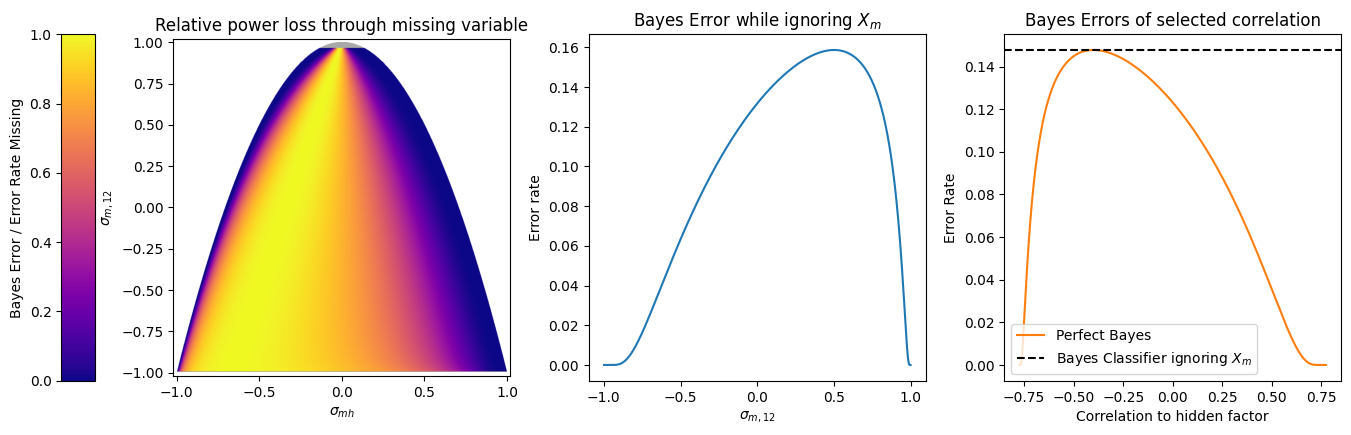

In [188]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

max_corrs = 1000

normalized_normed_errors, corr_space, bayes_err_no_hidden_valids_per_corr = calc_all_permissible_bayes_err(
    max_corrs=max_corrs,
    encoding_no_hidden_was_zero=-1,
    var_to_hide=base_sim_objs['var_to_hide']
)

max_vals, max_inds = normalized_normed_errors.nan_to_num(-20).max(dim=-1)

A, B = torch.meshgrid(corr_space, corr_space, indexing='ij')
comb_AB = torch.stack([A, B], dim=-1)


coords_highest = comb_AB[torch.arange(max_corrs), max_inds]
coords_highest_high_enough = coords_highest[max_vals > 0.999]

cmap = build_cmap_for_normalized_normed_errors(normalized_normed_errors)

corrs, bayes_errs_full, bayes_err_ignoring_var = get_bayes_err_comp_under_default_corr_mh(max_corrs, base_sim_objs['var_to_hide'])

fig = plt.figure(figsize=(16, 4.5))
gs = GridSpec(nrows=1, ncols=4, width_ratios=[0.1, 1, 1, 1], wspace=0.3, left=0.1)

# --- Colorbar axis (leftmost) ---
cax = fig.add_subplot(gs[0, 0])

ax = fig.add_subplot(gs[0, 1])

im = ax.imshow(
    normalized_normed_errors.numpy(),
    cmap,
    norm=mpl.colors.Normalize(vmin=0, vmax=1, clip=False),
    extent=[corr_space[0], corr_space[-1]]*2)

shift = 0.02
corrs_lims_map = [-1 - shift, 1 + shift]
ax.set_xlim(*corrs_lims_map)
ax.set_ylim(*corrs_lims_map)
ax.set_ylabel(r"$\sigma_{m,12}$")
ax.set_xlabel(r"$\sigma_{mh}$")
ax.set_title("Relative power loss through missing variable")


# attach colorbar to the dedicated axis
cb = fig.colorbar(im, cax=cax)

# Move ticks + label to the left
cb.ax.yaxis.set_label_position("left")
cb.ax.yaxis.tick_left()
cb.ax.yaxis.set_ticks_position("left")

cb.set_label("Bayes Error / Error Rate Missing")

ax = fig.add_subplot(gs[0, 2])
ax.plot(corr_space, bayes_err_no_hidden_valids_per_corr, c=mpl.colormaps["tab10"](0))
ax.set_xlabel(r"$\sigma_{m,12}$")
ax.set_ylabel(r"Error rate")
ax.set_title("Bayes Error while ignoring $X_m$")

ax = fig.add_subplot(gs[0, 3])

ax.plot(corrs, bayes_errs_full, c=mpl.colormaps["tab10"](1), label="Perfect Bayes")
ax.axhline(
    y=bayes_err_ignoring_var,
    label="Bayes Classifier ignoring $X_m$",
    ls = "--",
    c="k"
)
ax.set_xlabel("Correlation to hidden factor")
ax.set_ylabel("Error Rate")
ax.set_title("Bayes Errors of selected correlation")
ax.legend()


plt.show()



In [186]:
coords_highest

tensor([[-0.9980, -0.0310],
        [-0.9960, -0.0430],
        [-0.9940, -0.0529],
        ...,
        [ 0.9940, -0.7662],
        [ 0.9960, -0.9980],
        [ 0.9980, -0.9980]])

In [176]:
coords_highest.shape

torch.Size([1000, 2])

In [173]:
comb_AB[torch.arange(max_corrs), max_inds]

tensor([[-0.9980, -0.0310],
        [-0.9960, -0.0430],
        [-0.9940, -0.0529],
        ...,
        [ 0.9940, -0.7662],
        [ 0.9960, -0.9980],
        [ 0.9980, -0.9980]])

In [156]:
comb_AB.shape

torch.Size([500, 500, 2])

In [50]:
bayes_error_no_hidden_valids[22]

tensor(0.)

In [ ]:
mask_valid_AB.sum(dim=-1)

tensor([ 22,  32,  38,  44,  50,  54,  60,  64,  68,  70,  74,  78,  80,  84,
         86,  90,  92,  94,  98, 100, 102, 104, 108, 110, 112, 114, 116, 118,
        120, 122, 124, 126, 128, 130, 132, 134, 136, 138, 140, 142, 144, 146,
        146, 148, 150, 152, 154, 156, 156, 158, 160, 162, 162, 164, 166, 168,
        168, 170, 172, 174, 174, 176, 178, 180, 180, 182, 184, 184, 186, 188,
        188, 190, 192, 192, 194, 196, 196, 198, 198, 200, 202, 202, 204, 206,
        206, 208, 208, 210, 212, 212, 214, 214, 216, 218, 218, 220, 220, 222,
        222, 224, 224, 226, 228, 228, 230, 230, 232, 232, 234, 234, 236, 236,
        238, 238, 240, 242, 242, 244, 244, 246, 246, 248, 248, 250, 250, 252,
        252, 254, 254, 256, 256, 258, 258, 260, 260, 262, 262, 262, 264, 264,
        266, 266, 268, 268, 270, 270, 272, 272, 274, 274, 276, 276, 276, 278,
        278, 280, 280, 282, 282, 284, 284, 284, 286, 286, 288, 288, 290, 290,
        290, 292, 292, 294, 294, 296, 296, 296, 298, 298, 300, 3

In [99]:
covs[:, [0,1,2, 2], [2,2,1,2]]

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [ ]:
mask_valid_AB.sum(dim=-1)

tensor([ 22,  32,  38,  44,  50,  54,  60,  64,  68,  70,  74,  78,  80,  84,
         86,  90,  92,  94,  98, 100, 102, 104, 108, 110, 112, 114, 116, 118,
        120, 122, 124, 126, 128, 130, 132, 134, 136, 138, 140, 142, 144, 146,
        146, 148, 150, 152, 154, 156, 156, 158, 160, 162, 162, 164, 166, 168,
        168, 170, 172, 174, 174, 176, 178, 180, 180, 182, 184, 184, 186, 188,
        188, 190, 192, 192, 194, 196, 196, 198, 198, 200, 202, 202, 204, 206,
        206, 208, 208, 210, 212, 212, 214, 214, 216, 218, 218, 220, 220, 222,
        222, 224, 224, 226, 228, 228, 230, 230, 232, 232, 234, 234, 236, 236,
        238, 238, 240, 242, 242, 244, 244, 246, 246, 248, 248, 250, 250, 252,
        252, 254, 254, 256, 256, 258, 258, 260, 260, 262, 262, 262, 264, 264,
        266, 266, 268, 268, 270, 270, 272, 272, 274, 274, 276, 276, 276, 278,
        278, 280, 280, 282, 282, 284, 284, 284, 286, 286, 288, 288, 290, 290,
        290, 292, 292, 294, 294, 296, 296, 296, 298, 298, 300, 3

In [84]:
covs

tensor([[[ 1.0000, -0.9960,  1.0000],
         [-0.9960,  1.0000,  1.0000],
         [ 1.0000,  1.0000,  1.0000]],

        [[ 1.0000, -0.9960,  1.0000],
         [-0.9960,  1.0000,  1.0000],
         [ 1.0000,  1.0000,  1.0000]],

        [[ 1.0000, -0.9960,  1.0000],
         [-0.9960,  1.0000,  1.0000],
         [ 1.0000,  1.0000,  1.0000]],

        ...,

        [[ 1.0000,  0.9960,  1.0000],
         [ 0.9960,  1.0000,  1.0000],
         [ 1.0000,  1.0000,  1.0000]],

        [[ 1.0000,  0.9960,  1.0000],
         [ 0.9960,  1.0000,  1.0000],
         [ 1.0000,  1.0000,  1.0000]],

        [[ 1.0000,  0.9960,  1.0000],
         [ 0.9960,  1.0000,  1.0000],
         [ 1.0000,  1.0000,  1.0000]]])

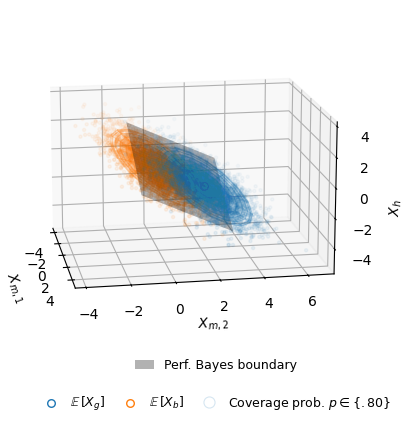

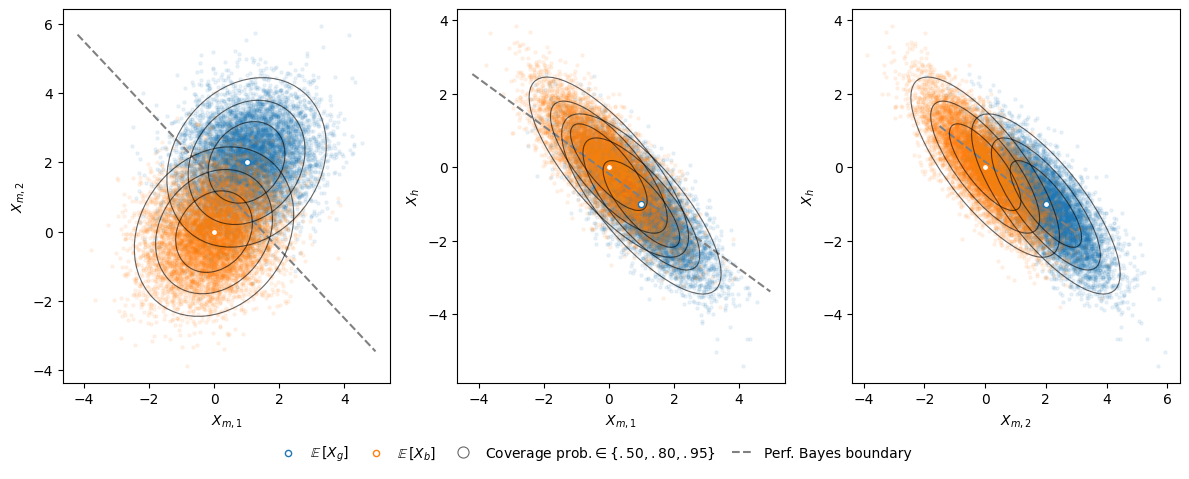

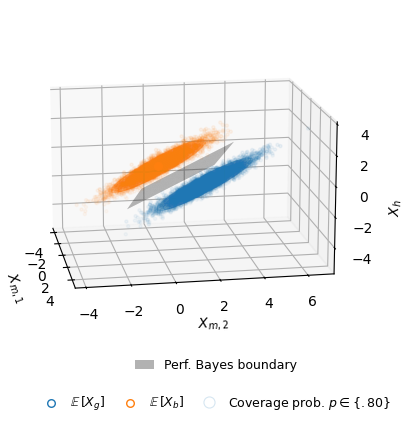

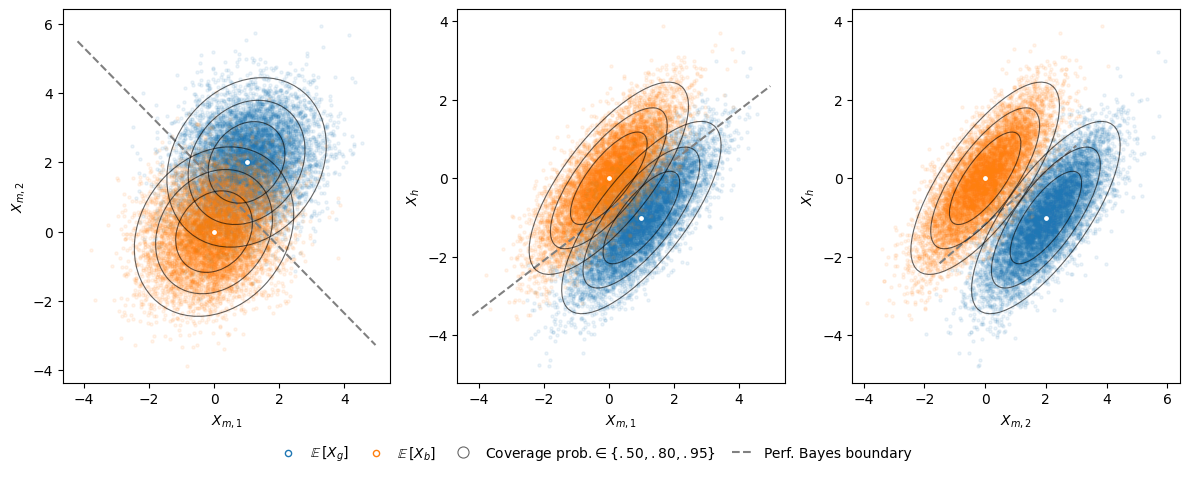

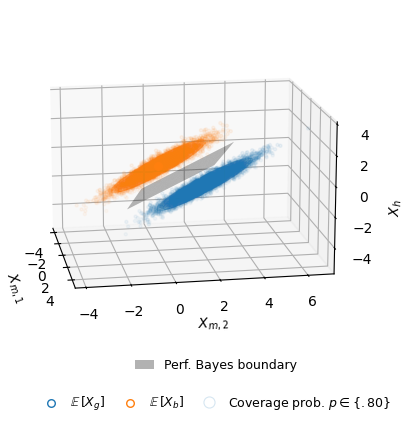

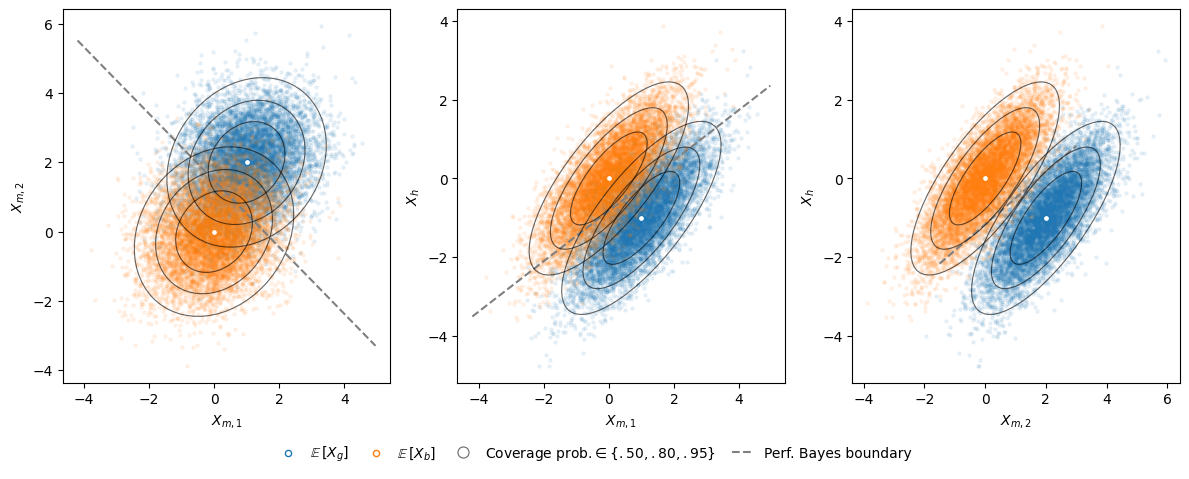

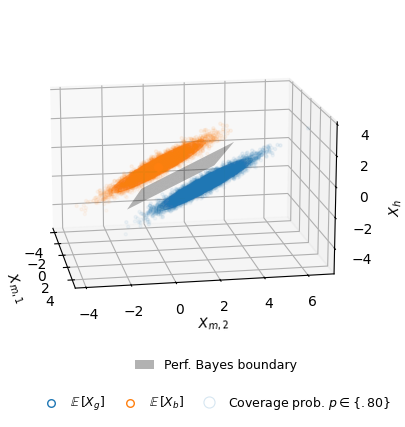

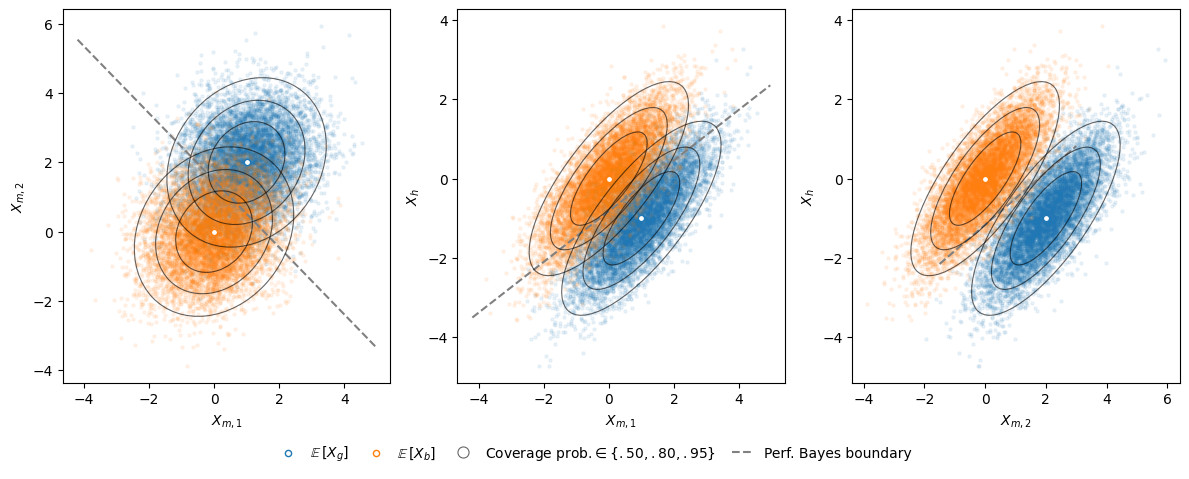

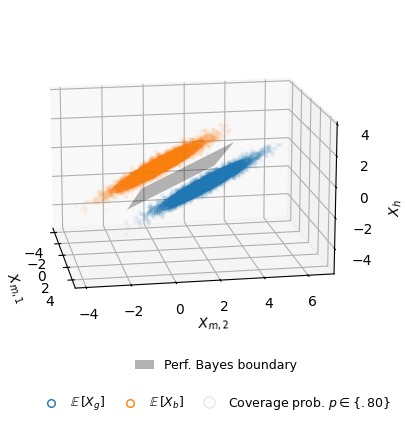

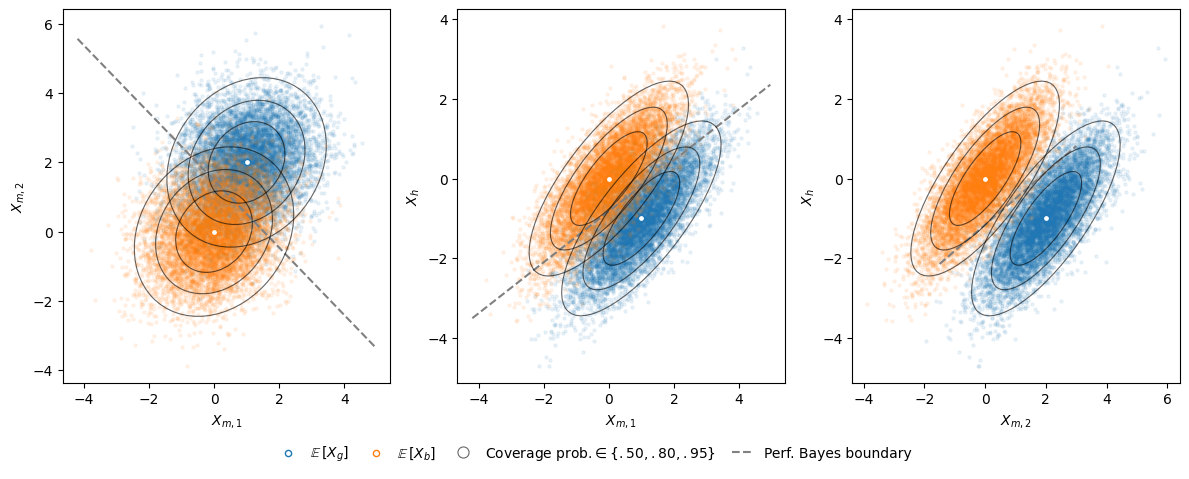

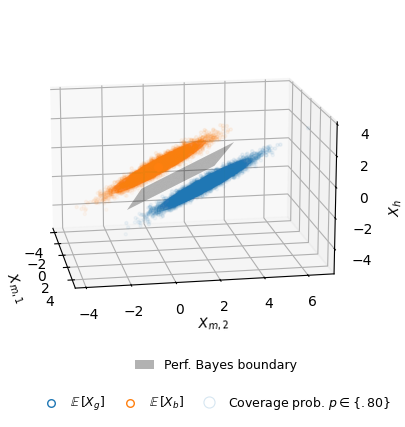

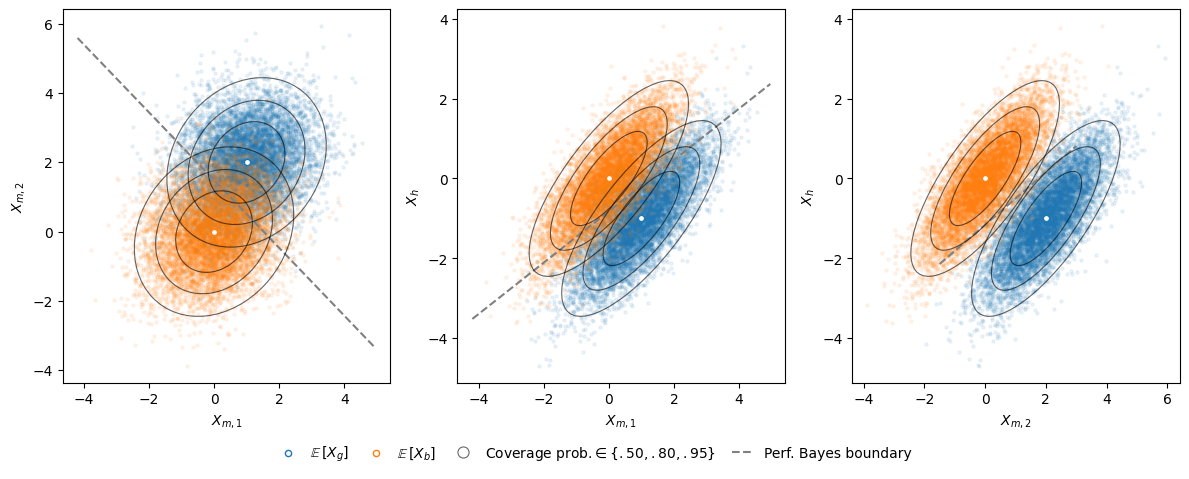

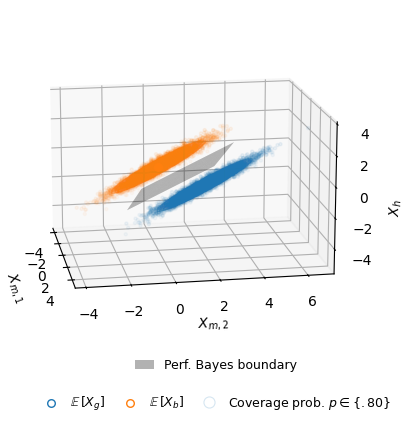

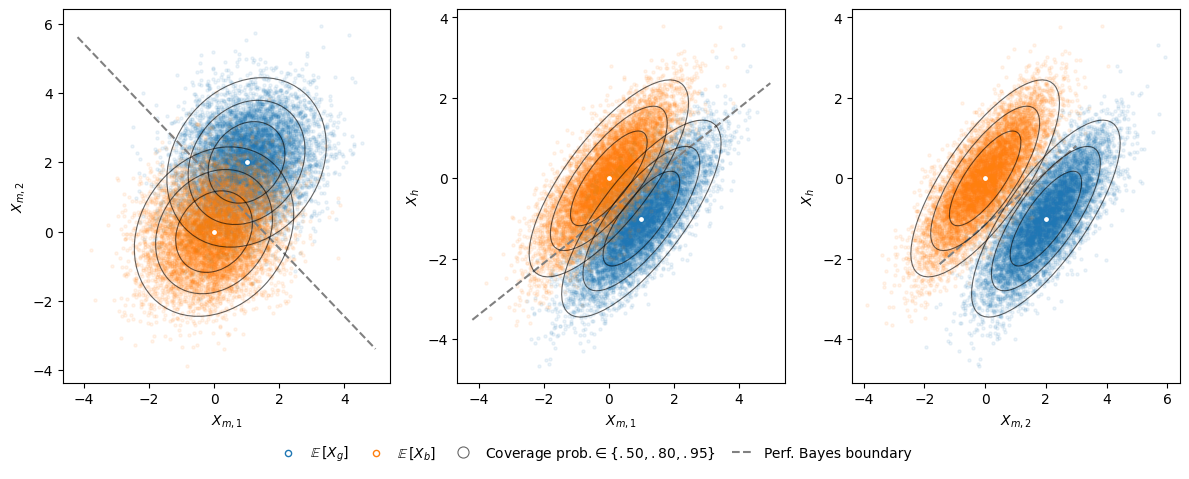

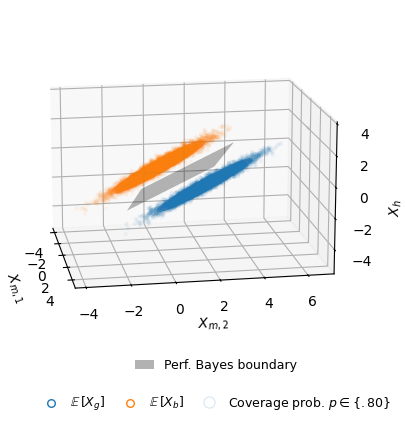

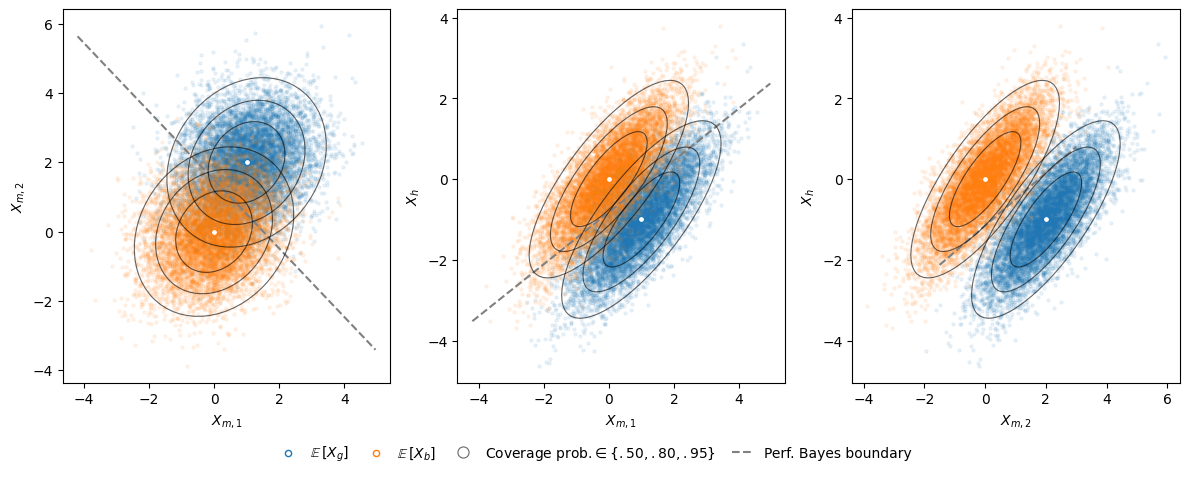

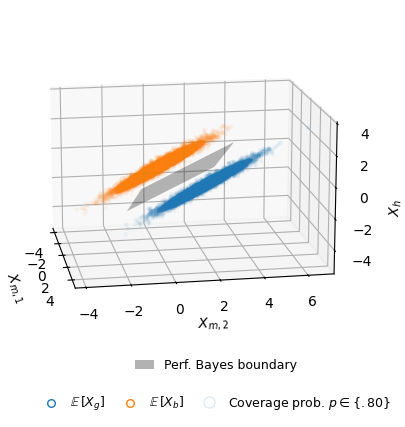

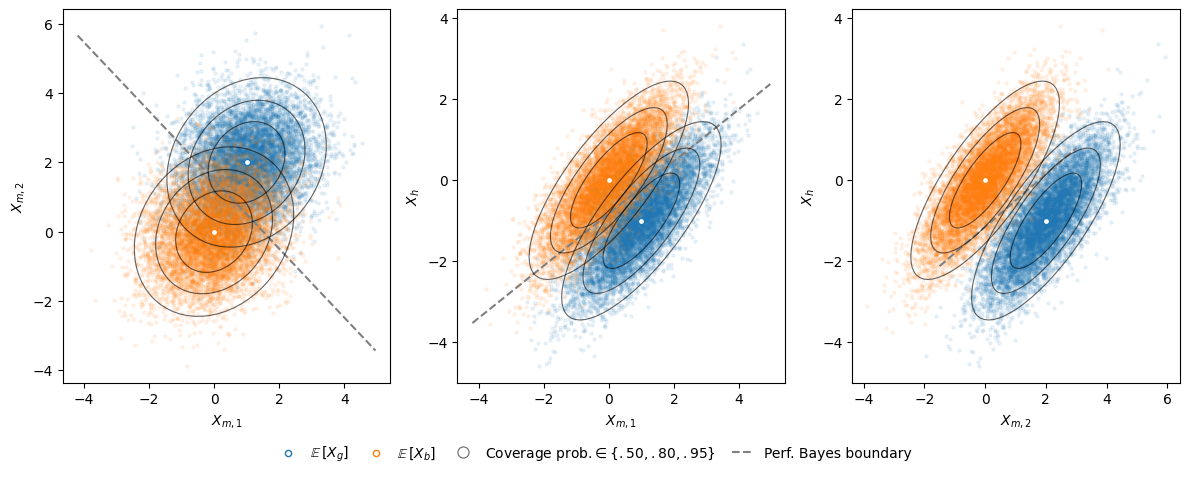

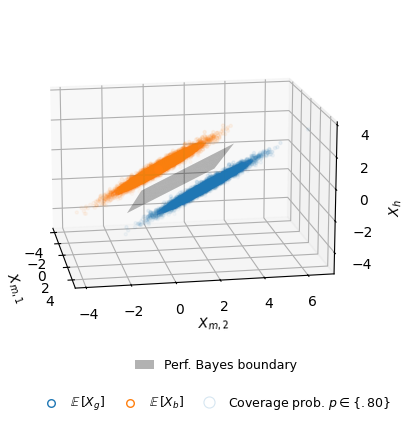

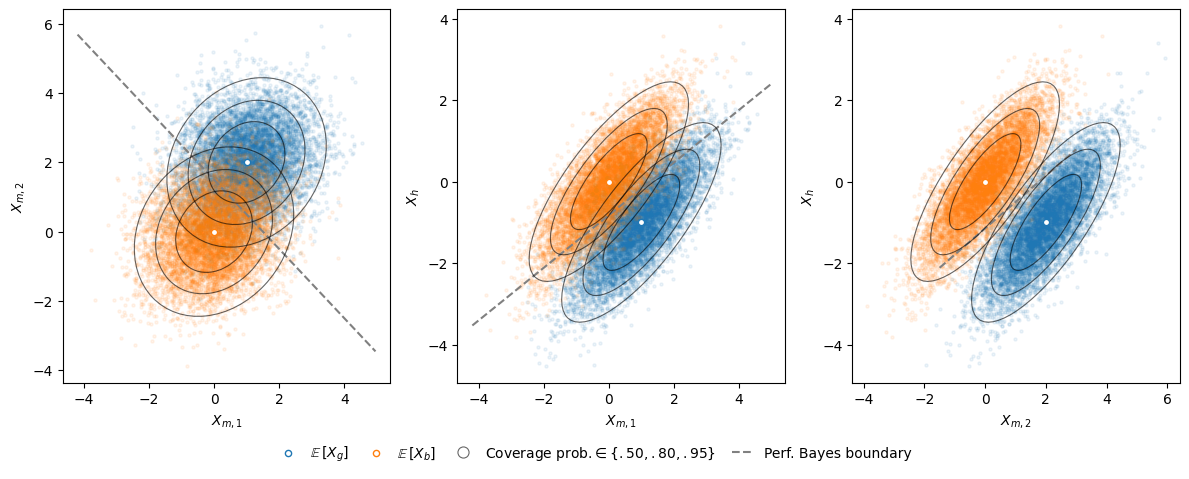

In [ ]:
from thesis.helper_scripts.dgp_plotting import (
  extract_dgp_info_for_boundaries,
  plot3d_with_perf_bayes_boundary,
  plot_pairwise_dgp_with_perf_bayes_boundaries
)

for corr in corrs[bayes_errs_full==0]:
    dgp_base = mnar_default_dgp(
        seed_credit_data_gen=1807,
        var_to_hide=base_sim_objs["var_to_hide"],
        hidden_corr=corr,
        deterministic_weights_for_mixture_sampling=False,
        device='cpu',
        dtype=torch.float32
    )
    dgp_info_for_boundaries = extract_dgp_info_for_boundaries(dgp_base)
    plot3d_with_perf_bayes_boundary(dgp_base, dgp_info_for_boundaries["W"], dgp_info_for_boundaries["bias"])
    plot_pairwise_dgp_with_perf_bayes_boundaries(dgp_base, **dgp_info_for_boundaries)


In [ ]:
bayes_errors = dgp_all_corrs.bayes_error_under_equal_covs()

tensor([0.0000e+00, 7.4342e-03, 3.3176e-02, 5.6933e-02, 7.5460e-02, 8.9737e-02,
        1.0088e-01, 1.0972e-01, 1.1683e-01, 1.2263e-01, 1.2739e-01, 1.3132e-01,
        1.3460e-01, 1.3732e-01, 1.3960e-01, 1.4149e-01, 1.4305e-01, 1.4433e-01,
        1.4537e-01, 1.4619e-01, 1.4682e-01, 1.4729e-01, 1.4760e-01, 1.4777e-01,
        1.4782e-01, 1.4776e-01, 1.4759e-01, 1.4732e-01, 1.4696e-01, 1.4651e-01,
        1.4599e-01, 1.4539e-01, 1.4472e-01, 1.4397e-01, 1.4317e-01, 1.4229e-01,
        1.4136e-01, 1.4036e-01, 1.3931e-01, 1.3820e-01, 1.3703e-01, 1.3581e-01,
        1.3453e-01, 1.3319e-01, 1.3180e-01, 1.3036e-01, 1.2886e-01, 1.2731e-01,
        1.2570e-01, 1.2404e-01, 1.2232e-01, 1.2055e-01, 1.1872e-01, 1.1683e-01,
        1.1488e-01, 1.1288e-01, 1.1081e-01, 1.0869e-01, 1.0650e-01, 1.0425e-01,
        1.0193e-01, 9.9550e-02, 9.7102e-02, 9.4586e-02, 9.2002e-02, 8.9347e-02,
        8.6620e-02, 8.3822e-02, 8.0950e-02, 7.8003e-02, 7.4983e-02, 7.1887e-02,
        6.8716e-02, 6.5472e-02, 6.2154e-

In [2]:
grid_path = '../berebasl/data/simulations/mnar_grid_hyp_testing'

grid_biases, grid_corrs = extract_biases_and_corrs_from_dirnames(grid_path)
grid_biases = dict(sorted(grid_biases.items(), key=lambda x: x[1]))
grid_corrs = dict(sorted(grid_corrs.items(), key=lambda x: x[1]))
all_sim_objs = extract_all_sim_objs(grid_path, grid_biases, grid_corrs)

In [3]:
bayes_errors = extract_bayes_errors(all_sim_objs, grid_biases, grid_corrs)
bayes_errors[0]

tensor([[0.1232, 0.1478],
        [0.0964, 0.1478],
        [0.0585, 0.1478],
        [0.0127, 0.1478]], dtype=torch.float64)

In [8]:
F = 50

hidden_vars = [-1, 10, 20, 51, -5]

for i, hv in enumerate(hidden_vars):
    if not (-F <= hv < F):
        raise IndexError(
                    f"Each element in hidden_vars must be in [-F, F-1] = [{-F}, {F-1}]. hidden_vars[{i}] was {hv}"
                )
    hidden_vars[i] = hv%F

hidden_vars

IndexError: Each element in hidden_vars must be in [-F, F-1] = [-50, 49]. hidden_vars[3] was 51

In [ ]:
plot_lines_and_mains(
    generate_line_collections_for_exp_real_plot(base_sim_objs),
    sample_sizes=base_sim_objs["sample_sizes"],
    add_fig_legend=True,
    add_legend=False
)

exp_to_real_diffs_base = generate_lines_for_diffs(base_sim_objs, make_abs=True, W=5)

plot_lines_and_mains(
    gen_lines_from_diff_dict(exp_to_real_diffs_base),
    sample_sizes=exp_to_real_diffs_base["sample_sizes"],
    add_fig_legend=True,
    add_legend=False,
    only_related_exp=True,
    diff_plot=True
)

In [ ]:
wrapper_plot_grid_of_diffs_between_logit_and_acc(all_sim_objs, grid_biases, grid_corrs)